# Travel Behavior Insights — EDA & Preprocessing

**Goal:** Explore the `train` and `test` datasets, perform EDA with visualizations, and build a
robust preprocessing pipeline including:

- missing-value handling,
- outlier handling (IQR capping / removal option),
- log / `log1p` transforms for skewed numeric features,
- simple feature engineering (ratios, binnings),
- categorical encoding aligned across train/test,
- scaling (fit on train only).

**Files used**
- Train: `train.csv`
- Test: `test.csv`
- Sample submission: `sample_submission.csv`

Run cells in order. Each code cell includes brief comments.


In [ ]:
# Code cell: imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
# Code cell: load train & test datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head(), test.head()


(           trip_id       country age_group             travel_companions  \
 0  tour_idftaa27vp        FRANCE     45-64      With Spouse and Children   
 1  tour_iduck75m57         KENYA     45-64                         Alone   
 2  tour_id8y3w40h8  SOUTH AFRICA     25-44  With Other Friends/Relatives   
 3  tour_idkoh8mkgr         ITALY     25-44                   With Spouse   
 4  tour_idkmsfa00a         ITALY     25-44                   With Spouse   
 
    num_females  num_males       main_activity            visit_purpose  \
 0          1.0        2.0       Beach Tourism     Leisure and Holidays   
 1          1.0        0.0  Conference Tourism  Meetings and Conference   
 2          2.0        0.0    Cultural Tourism  Meetings and Conference   
 3          1.0        1.0     Widlife Tourism     Leisure and Holidays   
 4          1.0        1.0       Beach Tourism     Leisure and Holidays   
 
   is_first_visit  mainland_stay_nights  ...  food_included  \
 0            Yes    

### 4. Dataset overview

We inspect:
- number of rows & columns
- column names
- data types
- compare train vs test structure


In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nData types:")
train.dtypes


Train shape: (12654, 25)
Test shape: (5852, 24)

Train columns:
['trip_id', 'country', 'age_group', 'travel_companions', 'num_females', 'num_males', 'main_activity', 'visit_purpose', 'is_first_visit', 'mainland_stay_nights', 'island_stay_nights', 'tour_type', 'intl_transport_included', 'info_source', 'accomodation_included', 'food_included', 'domestic_transport_included', 'sightseeing_included', 'guide_included', 'insurance_included', 'days_booked_before_trip', 'arrival_weather', 'total_trip_days', 'has_special_requirements', 'spend_category']

Test columns:
['trip_id', 'country', 'age_group', 'travel_companions', 'num_females', 'num_males', 'main_activity', 'visit_purpose', 'is_first_visit', 'mainland_stay_nights', 'island_stay_nights', 'tour_type', 'intl_transport_included', 'info_source', 'accomodation_included', 'food_included', 'domestic_transport_included', 'sightseeing_included', 'guide_included', 'insurance_included', 'days_booked_before_trip', 'arrival_weather', 'total_trip_da

,0
trip_id,object
country,object
age_group,object
travel_companions,object
num_females,float64
num_males,float64
main_activity,object
visit_purpose,object
is_first_visit,object
mainland_stay_nights,int64


### 5. Missing values

We calculate missing values for all features and visualize the top 10 missing columns.


In [ ]:
missing = train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(10)


,0
has_special_requirements,8117
arrival_weather,3403
days_booked_before_trip,1553
travel_companions,737
total_trip_days,402
insurance_included,236
country,230
food_included,171
intl_transport_included,147
accomodation_included,143


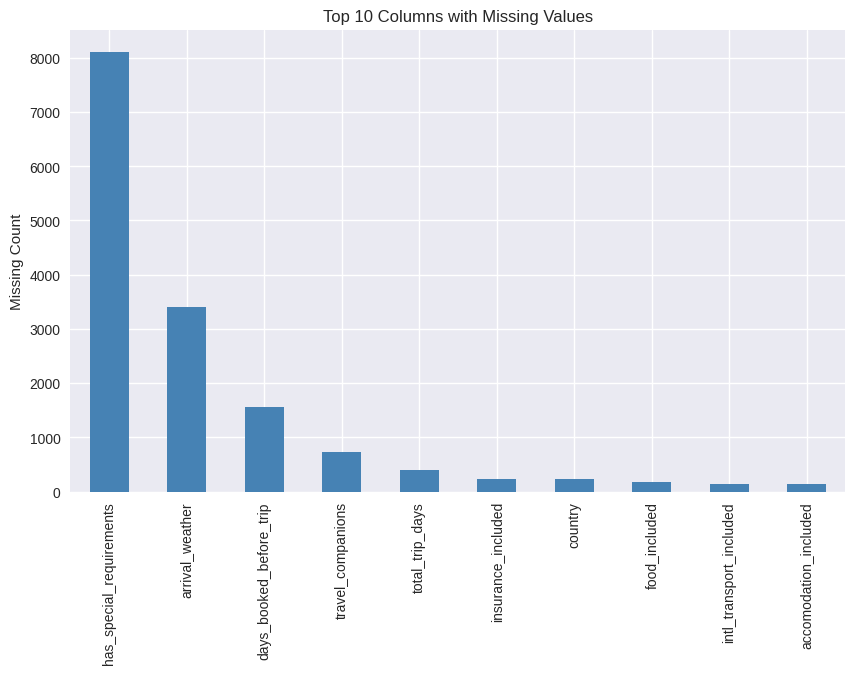

In [ ]:
# Barplot of missing values
missing.head(10).plot(kind="bar", color="steelblue")
plt.title("Top 10 Columns with Missing Values")
plt.ylabel("Missing Count")
plt.show()


### 6. Target Variable: `spend_category`

We analyze the distribution of the target variable to understand class balance.

`spend_category` has 3 classes:
- **0 → Low spenders**
- **1 → Medium spenders**
- **2 → High spenders**

A balanced or imbalanced dataset affects model choice and evaluation.


In [ ]:
# Count the target classes
train['spend_category'].value_counts()


,count
spend_category,
0.0,6245
1.0,4911
2.0,1464


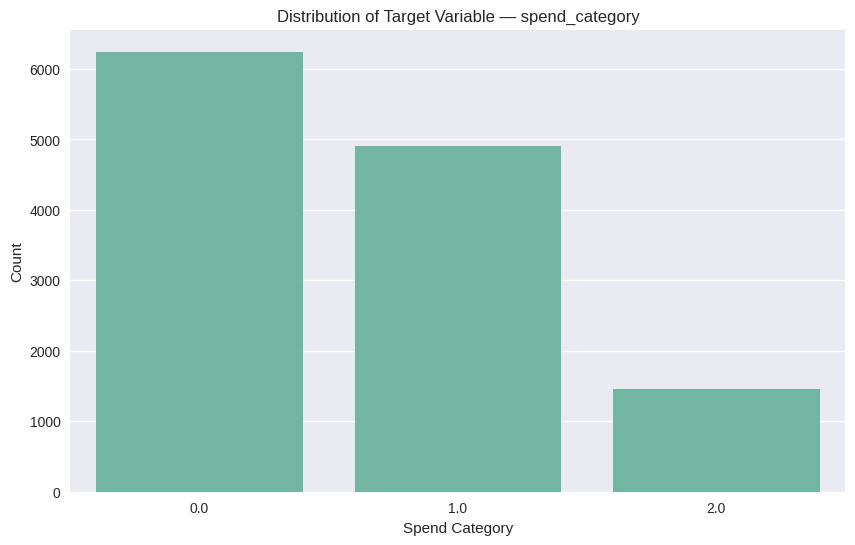

In [ ]:
# Plot distribution
sns.countplot(data=train, x='spend_category')
plt.title("Distribution of Target Variable — spend_category")
plt.xlabel("Spend Category")
plt.ylabel("Count")
plt.show()


### 7. Separate numerical and categorical features

We automatically split columns into:
- numerical features
- categorical features

This helps in applying correct EDA and preprocessing steps.


In [ ]:
# Identify numeric and categorical columns
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

# Remove target & ID from numerical list
if 'spend_category' in numeric_cols:
    numeric_cols.remove('spend_category')
if 'trip_id' in categorical_cols:
    categorical_cols.remove('trip_id')

numeric_cols, categorical_cols


(['num_females', 'num_males', 'mainland_stay_nights', 'island_stay_nights'],
 ['country',
  'age_group',
  'travel_companions',
  'main_activity',
  'visit_purpose',
  'is_first_visit',
  'tour_type',
  'intl_transport_included',
  'info_source',
  'accomodation_included',
  'food_included',
  'domestic_transport_included',
  'sightseeing_included',
  'guide_included',
  'insurance_included',
  'days_booked_before_trip',
  'arrival_weather',
  'total_trip_days',
  'has_special_requirements'])

### 8. Summary statistics for numerical features


In [ ]:
train[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
num_females,12652.0,0.943724,1.268167,0.0,0.0,1.0,1.0,49.0
num_males,12650.0,1.009407,1.234850,0.0,1.0,1.0,1.0,58.0
mainland_stay_nights,12654.0,9.205073,14.548536,0.0,3.0,6.0,11.0,365.0
island_stay_nights,12654.0,2.516833,5.132266,0.0,0.0,0.0,4.0,240.0


### 9. Categorical variable overview

For each categorical column, we display:
- number of unique values
- top 5 most frequent categories


In [ ]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", train[col].nunique())
    print(train[col].value_counts().head())



Column: country
Unique values: 123
country
UNITED STATES OF AMERICA    1953
UNITED KINGDOM              1415
ITALY                       1125
FRANCE                       738
GERMANY                      655
Name: count, dtype: int64

Column: age_group
Unique values: 5
age_group
25-44    6146
45-64    3907
18-24    1500
65+      1011
<18        82
Name: count, dtype: int64

Column: travel_companions
Unique values: 5
travel_companions
Alone                           5088
With Spouse                     3389
With Other Friends/Relatives    2221
With Spouse and Children         849
With Children                    370
Name: count, dtype: int64

Column: main_activity
Unique values: 10
main_activity
Widlife Tourism       4096
Beach Tourism         2860
Wildlife Tourism      1565
Conference Tourism    1324
Hunting Tourism       1090
Name: count, dtype: int64

Column: visit_purpose
Unique values: 8
visit_purpose
Leisure and Holidays              8207
Visiting Friends and Relatives    1527
Bu

### 10. Correlation heatmap

Although most features are categorical, we visualize correlations
among numerical features to understand relationships and detect
possible multicollinearity.


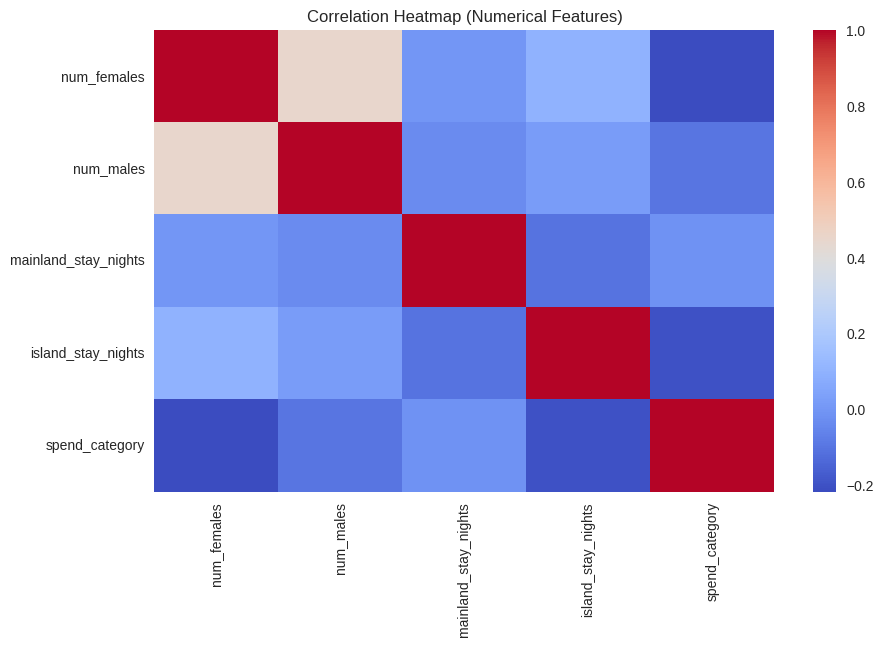

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(train[numeric_cols + ['spend_category']].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


### 11. Outlier analysis

We visualize boxplots for numerical columns to detect outliers using IQR.
Only for key columns such as:
- `num_females`
- `num_males`
- `mainland_stay_nights`
- `island_stay_nights`

These features may require outlier capping/removal later.


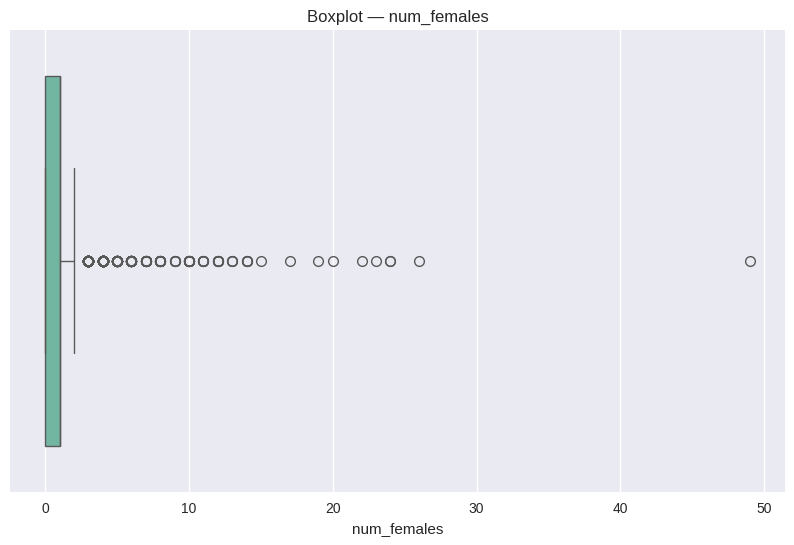

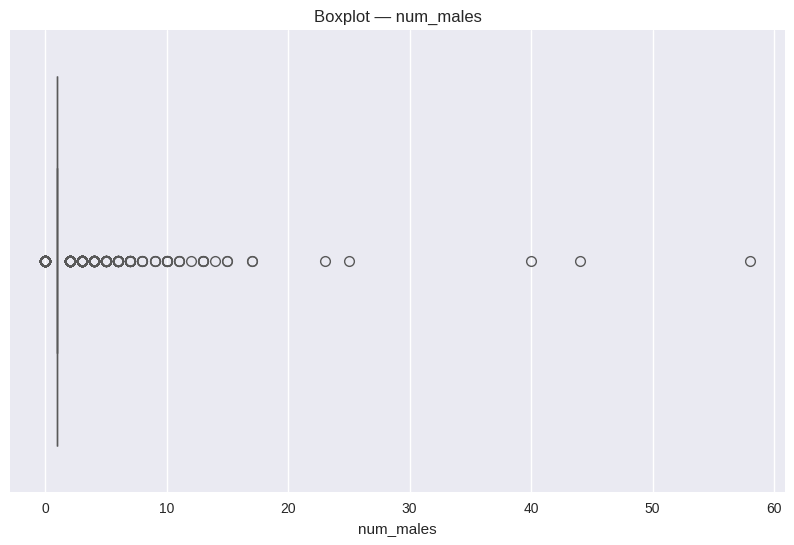

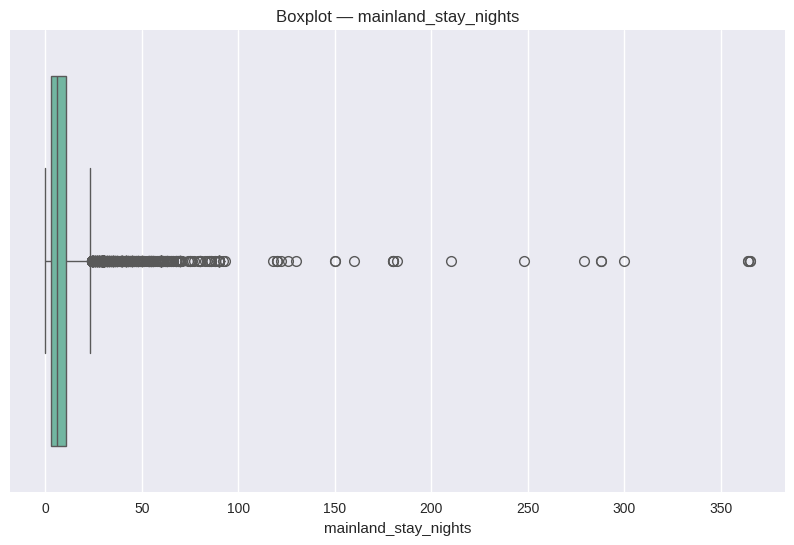

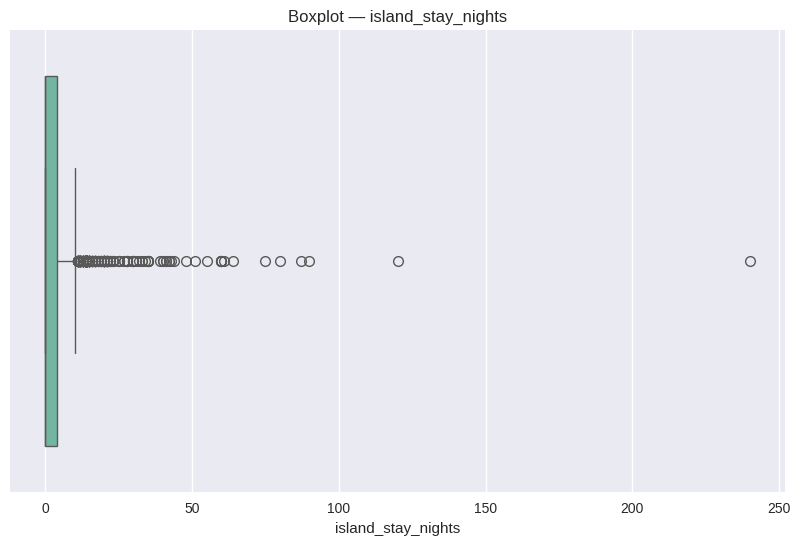

In [ ]:
cols_to_plot = ['num_females', 'num_males', 'mainland_stay_nights', 'island_stay_nights']

for col in cols_to_plot:
    plt.figure()
    sns.boxplot(data=train, x=col)
    plt.title(f"Boxplot — {col}")
    plt.show()


### 12. Skewness check for numerical features

Skewed columns may need `log1p()` transform.


In [ ]:
train[numeric_cols].skew().sort_values(ascending=False)


,0
num_males,16.713396
island_stay_nights,12.327580
mainland_stay_nights,9.990956
num_females,9.654998


### 13. Preprocessing — Overview

We will now clean and transform the dataset using the following steps:

1. **Handle missing values**
   - Categorical → fill with mode / "Unknown"
   - Numerical → fill with median

2. **Outlier handling (IQR capping)**
   - Apply to numerical columns with visible outliers:
     - num_females
     - num_males
     - mainland_stay_nights
     - island_stay_nights

3. **Log transforms (log1p)**
   - Apply to skewed duration/stay columns (after checking skewness)

4. **Feature engineering**
   - total_group_size = num_females + num_males
   - is_family_trip (children/spouse)
   - is_group_trip (friends/relatives)
   - mainland_to_island_ratio

5. **Encode categorical variables**
   - One-Hot Encoding for all categorical variables

6. **Scale numerical features**
   - Use StandardScaler (fit on train, transform test)

7. **Align train and test columns**
   - Ensure both datasets have identical feature columns

8. **Prepare final X_train, y_train, X_test**


### 14. Missing Value Imputation

Rules:
- **Categorical columns** → fill with `"Unknown"`
- **Numerical columns** → fill with median

We apply the exact same transformations to both train and test.


In [ ]:
# Copy datasets to avoid modifying original
train_clean = train.copy()
test_clean = test.copy()

# Identify numerical & categorical columns
num_cols = train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_clean.select_dtypes(include=['object']).columns.tolist()

# Remove ID and target
num_cols = [c for c in num_cols if c not in ['spend_category']]
cat_cols = [c for c in cat_cols if c not in ['trip_id']]

# Numerical: fill with median
for col in num_cols:
    median_val = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_val)
    test_clean[col] = test_clean[col].fillna(median_val)

# Categorical: fill with "Unknown"
for col in cat_cols:
    train_clean[col] = train_clean[col].fillna("Unknown")
    test_clean[col] = test_clean[col].fillna("Unknown")


### 15. Outlier Handling — IQR Capping

We cap extreme values (not remove rows) to prevent distortion.

Columns capped:
- num_females
- num_males
- mainland_stay_nights
- island_stay_nights


In [ ]:
outlier_cols = ['num_females', 'num_males', 'mainland_stay_nights', 'island_stay_nights']

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

for col in outlier_cols:
    train_clean = cap_outliers(train_clean, col)
    test_clean = cap_outliers(test_clean, col)


### 16. Log Transform

We apply `log1p()` to reduce skewness for:
- mainland_stay_nights
- island_stay_nights

These represent count/duration variables.


In [ ]:
log_cols = ['mainland_stay_nights', 'island_stay_nights']

for col in log_cols:
    train_clean[col] = np.log1p(train_clean[col])
    test_clean[col] = np.log1p(test_clean[col])


### 17. Feature Engineering

We create new features that better capture trip behavior:

- **total_group_size** = num_females + num_males  
- **is_family_trip** = 1 if companions involve spouse/children  
- **is_group_trip** = 1 if companions involve friends/relatives  
- **mainland_to_island_ratio** = ratio of stays (handle divide by zero)


In [ ]:
# Group size
train_clean['total_group_size'] = train_clean['num_females'] + train_clean['num_males']
test_clean['total_group_size'] = test_clean['num_females'] + test_clean['num_males']

# Family trip indicator
train_clean['is_family_trip'] = train_clean['travel_companions'].isin(
    ['With Spouse', 'With Children']
).astype(int)

test_clean['is_family_trip'] = test_clean['travel_companions'].isin(
    ['With Spouse', 'With Children']
).astype(int)

# Group trip indicator
train_clean['is_group_trip'] = train_clean['travel_companions'].isin(
    ['With Friends/Relatives']
).astype(int)

test_clean['is_group_trip'] = test_clean['travel_companions'].isin(
    ['With Friends/Relatives']
).astype(int)

# Ratio feature
train_clean['mainland_to_island_ratio'] = (
    train_clean['mainland_stay_nights'] / (train_clean['island_stay_nights'] + 1)
)

test_clean['mainland_to_island_ratio'] = (
    test_clean['mainland_stay_nights'] / (test_clean['island_stay_nights'] + 1)
)


### 18. One-Hot Encoding

We convert categorical columns into numeric dummy variables.
We then align train and test to have identical columns.


In [ ]:
# One-hot encode
train_encoded = pd.get_dummies(train_clean, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test_clean, columns=cat_cols, drop_first=True)

# Align train and test
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1)

# Fill NaNs in test (from missing dummy columns)
test_encoded = test_encoded.fillna(0)


### 19. Standardization (Z-Score Scaling)

We standardize selected numerical features using:

\[
z = \frac{x - \mu}{\sigma}
\]

Standardization ensures all numerical features have **mean = 0** and **std = 1**, which helps ML models
(XGBoost, Logistic Regression, Neural Nets, etc.).

Columns scaled:
- num_females  
- num_males  
- mainland_stay_nights  
- island_stay_nights  
- total_group_size  
- mainland_to_island_ratio  

We fit the scaler **only on the training set** to avoid data leakage.


In [ ]:
# ---------------------------------------------
# STANDARDIZATION (Z-SCORE SCALING)
# ---------------------------------------------
from sklearn.preprocessing import StandardScaler
import numpy as np

# Columns chosen for standardization
candidate_scale = [
    "num_females", "num_males",
    "mainland_stay_nights", "island_stay_nights",
    "total_group_size", "mainland_to_island_ratio"
]

# Keep only those present in encoded dataframes
scale_cols = [c for c in candidate_scale if c in train_encoded.columns]

print("Columns that will be standardized:", scale_cols)

# Apply StandardScaler
scaler = StandardScaler()
train_encoded[scale_cols] = scaler.fit_transform(train_encoded[scale_cols].astype(float))
test_encoded[scale_cols]  = scaler.transform(test_encoded[scale_cols].astype(float))

# ---------------------------------------------
# FINAL DATA PREPARATION
# ---------------------------------------------
train_preprocessed = train_encoded.copy()
test_preprocessed = test_encoded.copy()

# Ensure trip_id stays in output
if "trip_id" not in train_preprocessed.columns:
    train_preprocessed["trip_id"] = train["trip_id"]

if "trip_id" not in test_preprocessed.columns:
    test_preprocessed["trip_id"] = test["trip_id"]

# Order: trip_id → spend_category → remaining features
cols = train_preprocessed.columns.tolist()
final_order = []

if "trip_id" in cols:
    final_order.append("trip_id")
if "spend_category" in cols:
    final_order.append("spend_category")

for c in cols:
    if c not in final_order:
        final_order.append(c)

train_preprocessed = train_preprocessed[final_order]

# For test: trip_id first
test_cols = test_preprocessed.columns.tolist()
if "trip_id" in test_cols:
    test_cols.remove("trip_id")
test_preprocessed = test_preprocessed[["trip_id"] + test_cols]

# ---------------------------------------------
# SAVE OUTPUT FILES
# ---------------------------------------------
train_preprocessed.to_csv("train_preprocessed.csv", index=False)
test_preprocessed.to_csv("test_preprocessed.csv", index=False)

print("Saved files:")
print(" - train_preprocessed.csv", train_preprocessed.shape)
print(" - test_preprocessed.csv", test_preprocessed.shape)


Columns that will be standardized: ['num_females', 'num_males', 'mainland_stay_nights', 'island_stay_nights', 'total_group_size', 'mainland_to_island_ratio']
Saved files:
 - train_preprocessed.csv (12654, 202)
 - test_preprocessed.csv (5852, 202)
